# Taller K-Means - Inteligencia Artificial

**Integrantes del grupo:**
- Iván Parra Rodelo
- Juan Bauz Villa
- Kevin Ruiz

Generamos un dataset sintético con 6 clusters (2 de ellos solapados) más outliers, y aplicamos K-Means comparando tres formas de elegir el K óptimo: codo, Silhouette y una basada en las etiquetas reales.


## 1. Generación de los datos

Creamos 6 clusters gaussianos isotrópicos, todos con 200 puntos pero con `sigma` distinto (así quedan con distinta densidad). Los clusters 4 y 5 los ubicamos cerca a propósito para que se solapen un poco. Todo se genera dentro de [-10, 10] y le agregamos un 5% de outliers uniformes.


In [1]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
try:
    import pandas as pd
    import seaborn as sns
except ImportError:
    %pip install pandas seaborn
    import pandas as pd
    import seaborn as sns
try:
    from sklearn.cluster import KMeans
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        adjusted_rand_score,
        normalized_mutual_info_score,
        accuracy_score,
        confusion_matrix,
        classification_report,
    )
    from sklearn.preprocessing import StandardScaler
except ImportError:
    %pip install scikit-learn
    from sklearn.cluster import KMeans
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        adjusted_rand_score,
        normalized_mutual_info_score,
        accuracy_score,
        confusion_matrix,
        classification_report,
    )
    from sklearn.preprocessing import StandardScaler
try:
    from scipy.stats import mode
except ImportError:
    %pip install scipy
    from scipy.stats import mode

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 21.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 46.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
rng = np.random.default_rng(42)

# --------------------------------------------------------------------------
# Definición de los 6 clusters: centros y desviaciones estándar distintas
# (distinta densidad, mismo número de puntos por cluster).
# Los clusters 4 y 5 se ubican cerca uno del otro para que se superpongan
# parcialmente.
# --------------------------------------------------------------------------
n_per_cluster = 200          # mismo número de puntos en cada cluster
n_clusters_true = 6

centers = np.array([
    [-6.5,  6.5],   # cluster 0 - esquina superior izquierda
    [ 6.5,  6.5],   # cluster 1 - esquina superior derecha
    [-6.5, -6.5],   # cluster 2 - esquina inferior izquierda
    [ 6.5, -6.5],   # cluster 3 - esquina inferior derecha
    [-1.0, -1.0],   # cluster 4 - centro          \
    [ 1.3,  0.4],   # cluster 5 - cerca del centro / se superpone con el 4
])

stds = np.array([0.40, 0.70, 0.50, 0.90, 0.60, 0.80])  # densidades distintas

X_clusters, y_true = [], []
for i in range(n_clusters_true):
    pts = rng.normal(loc=centers[i], scale=stds[i], size=(n_per_cluster, 2))
    X_clusters.append(pts)
    y_true.extend([i] * n_per_cluster)

X_clusters = np.vstack(X_clusters)
y_true = np.array(y_true)

# Nos aseguramos de que ningún punto quede fuera del rango [-10, 10]
X_clusters = np.clip(X_clusters, -10, 10)

# Outliers: distribución uniforme en [-10, 10] x [-10, 10]

outlier_fraction = 0.05
n_outliers = int(outlier_fraction * len(X_clusters))
X_outliers = rng.uniform(-10, 10, size=(n_outliers, 2))

X_all = np.vstack([X_clusters, X_outliers])
y_all = np.concatenate([y_true, np.full(n_outliers, -1)])  # -1 = outlier

print(f"Puntos por cluster: {n_per_cluster}  |  Número de clusters: {n_clusters_true}")
print(f"Desviaciones estándar por cluster: {stds}")
print(f"Outliers generados: {n_outliers}")
print(f"Total de puntos en el dataset: {len(X_all)}")
print(f"Rango de X1: [{X_all[:,0].min():.2f}, {X_all[:,0].max():.2f}]")
print(f"Rango de X2: [{X_all[:,1].min():.2f}, {X_all[:,1].max():.2f}]")


Puntos por cluster: 200  |  Número de clusters: 6
Desviaciones estándar por cluster: [0.4 0.7 0.5 0.9 0.6 0.8]
Outliers generados: 60
Total de puntos en el dataset: 1260
Rango de X1: [-9.75, 9.40]
Rango de X2: [-9.67, 9.91]


## 2. Visualización de los datos

Graficamos todo para comprobar que quedó como queríamos: los 6 grupos dentro del rango, el 4 y el 5 pegados, y los outliers regados por todo el plano.


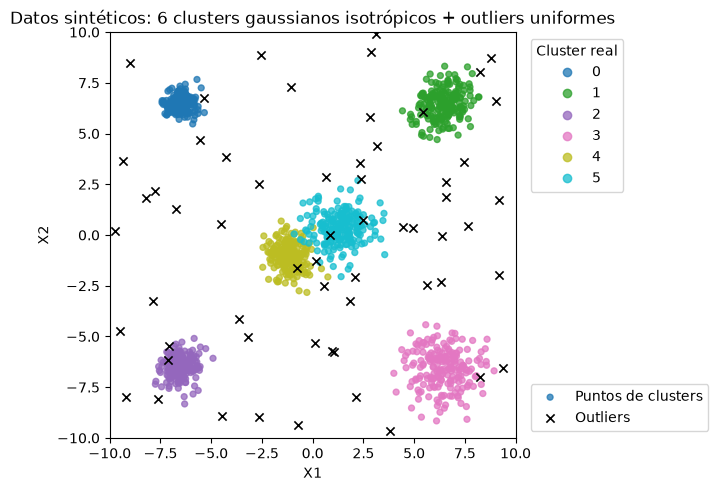

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
scatter = ax.scatter(
    X_clusters[:, 0], X_clusters[:, 1],
    c=y_true, cmap="tab10", s=18, alpha=0.75, label="Puntos de clusters"
)
ax.scatter(
    X_outliers[:, 0], X_outliers[:, 1],
    c="black", marker="x", s=35, linewidths=1.2, label="Outliers"
)
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster real", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Datos sintéticos: 6 clusters gaussianos isotrópicos + outliers uniformes")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()




## 3. Remoción de outliers

K-Means es sensible a outliers porque afectan la posición de los centroides, así que los quitamos antes de correr el algoritmo. Usamos Local Outlier Factor (LOF), que marca como outlier a los puntos que están en zonas de baja densidad respecto a sus vecinos. Le pusimos `contamination` similar al 5% que usamos para generarlos.


In [4]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=outlier_fraction)
y_pred_lof = lof.fit_predict(X_all)          # 1 = inlier, -1 = outlier detectado
lof_scores = lof.negative_outlier_factor_

mask_inliers = y_pred_lof == 1
X_clean = X_all[mask_inliers]
y_all_clean = y_all[mask_inliers]            # puede contener -1 si algún outlier no fue detectado

print(f"Puntos totales:              {len(X_all)}")
print(f"Detectados como outliers:    {(~mask_inliers).sum()}")
print(f"Puntos restantes (limpios):  {len(X_clean)}")

# Puntos con etiqueta real conocida (cluster 0-5) que sobrevivieron a la limpieza.
# Los usaremos más adelante para el método basado en ground truth.
mask_known_cluster = y_all_clean != -1
y_true_clean = y_all_clean[mask_known_cluster]

print(f"De esos, con etiqueta real conocida (para ground truth): {mask_known_cluster.sum()}")


Puntos totales:              1260
Detectados como outliers:    63
Puntos restantes (limpios):  1197
De esos, con etiqueta real conocida (para ground truth): 1186


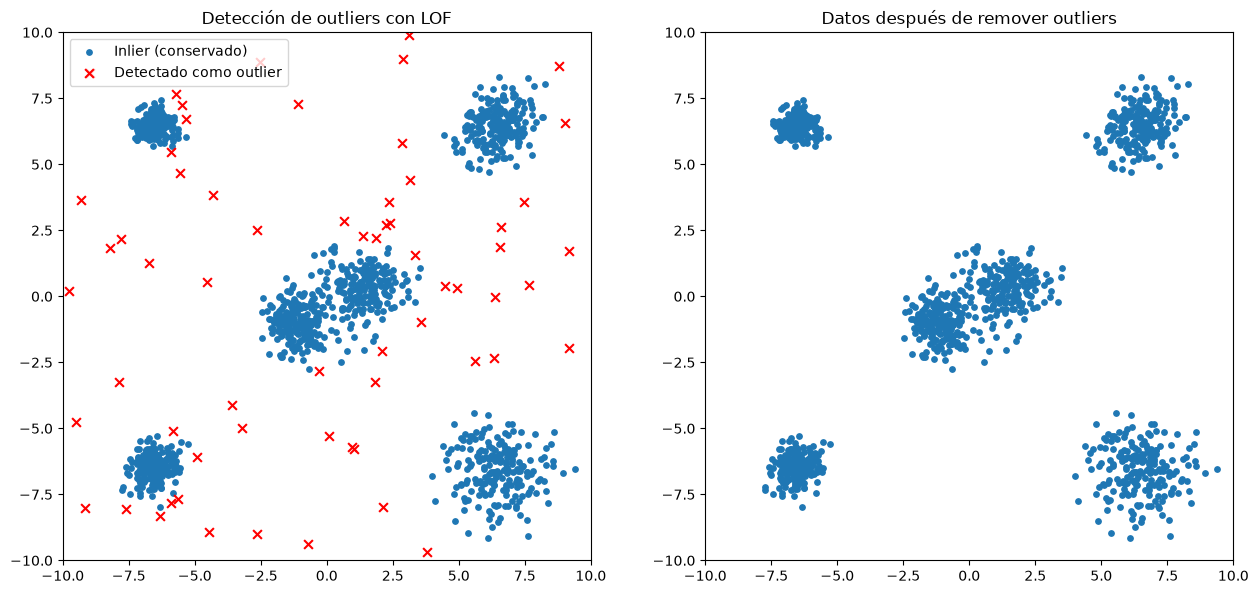

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(X_all[mask_inliers, 0], X_all[mask_inliers, 1], c="tab:blue", s=15, label="Inlier (conservado)")
axes[0].scatter(X_all[~mask_inliers, 0], X_all[~mask_inliers, 1], c="red", marker="x", s=40, label="Detectado como outlier")
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10); axes[0].set_aspect("equal")
axes[0].set_title("Detección de outliers con LOF")
axes[0].legend()

axes[1].scatter(X_clean[:, 0], X_clean[:, 1], c="tab:blue", s=15)
axes[1].set_xlim(-10, 10); axes[1].set_ylim(-10, 10); axes[1].set_aspect("equal")
axes[1].set_title("Datos después de remover outliers")

plt.tight_layout()
plt.show()


## 4. K-Means para K entre 2 y 12

Con los datos ya limpios (`X_clean`), corremos K-Means para cada K de 2 a 12 y guardamos de una vez todo lo que necesitamos: inercia (para el codo), silhouette promedio, y ARI/NMI contra las etiquetas reales (calculados solo sobre los puntos que sabemos a qué cluster real pertenecen).


In [6]:
k_range = range(2, 13)  # de 2 a 12 clusters

inertias = []
silhouette_avgs = []
ari_scores = []
nmi_scores = []
models = {}

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred = kmeans_k.fit_predict(X_clean)
    models[k] = kmeans_k

    inertias.append(kmeans_k.inertia_)
    silhouette_avgs.append(silhouette_score(X_clean, labels_pred))

    labels_pred_known = labels_pred[mask_known_cluster]
    ari_scores.append(adjusted_rand_score(y_true_clean, labels_pred_known))
    nmi_scores.append(normalized_mutual_info_score(y_true_clean, labels_pred_known))

resultados = pd.DataFrame({
    "K": list(k_range),
    "Inercia": inertias,
    "Silhouette": silhouette_avgs,
    "ARI": ari_scores,
    "NMI": nmi_scores,
})
resultados


,K,Inercia,Silhouette,ARI,NMI
0,2,42257.411751,0.378835,0.313655,0.512632
1,3,26398.517871,0.545875,0.333989,0.653463
2,4,12629.830708,0.682496,0.574157,0.817278
3,5,1891.908374,0.826411,0.823996,0.931332
4,6,1080.174768,0.773065,0.974556,0.975623
5,7,952.874932,0.690713,0.920731,0.944904
6,8,870.267280,0.606790,0.863140,0.916121
7,9,786.183154,0.613645,0.844395,0.900578
8,10,711.198342,0.562421,0.797772,0.880477
9,11,661.832783,0.560741,0.780065,0.866531


## 5. Método del codo

La inercia siempre baja al aumentar K, así que buscamos el punto donde deja de bajar tan rápido.


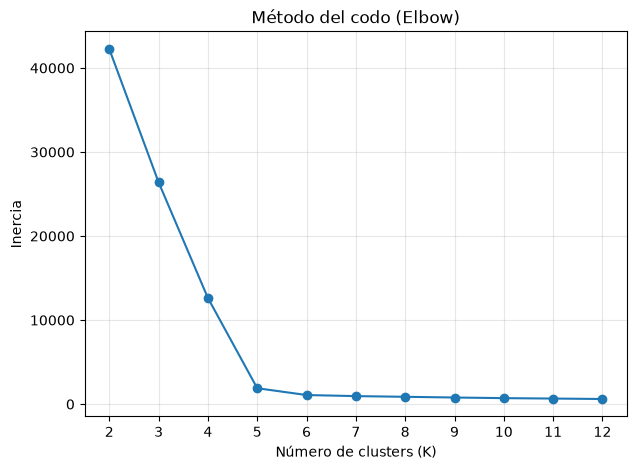

K sugerido por el método del codo (heurística de 2da derivada): 5


In [7]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo (Elbow)")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

# Heurística simple para ubicar el "codo": el K que maximiza la
# segunda derivada discreta de la curva de inercia (mayor cambio de pendiente).
inertias_arr = np.array(inertias)
primera_diff = np.diff(inertias_arr)
segunda_diff = np.diff(primera_diff)
k_codo = list(k_range)[int(np.argmax(segunda_diff)) + 1]
print(f"K sugerido por el método del codo (heurística de 2da derivada): {k_codo}")


El codo es un criterio bastante subjetivo, por eso agregamos la heurística de la segunda derivada, pero igual conviene mirar la gráfica.

## 6. Coeficiente de Silhouette

Mide qué tan parecido es cada punto a su propio cluster frente a qué tan parecido es al cluster más cercano. Tomamos el K que maximiza el promedio.


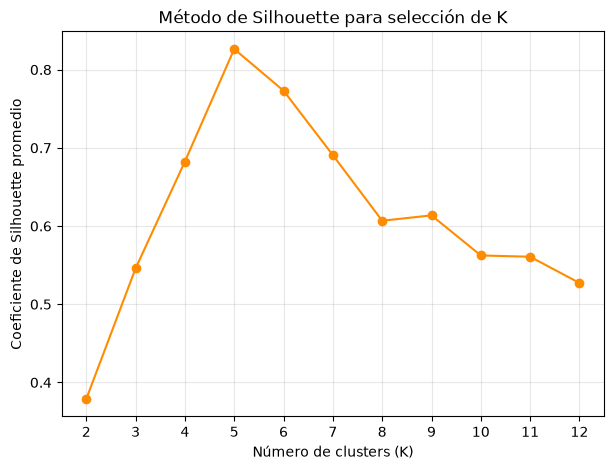

K óptimo según Silhouette: 5 (score = 0.8264)


In [8]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), silhouette_avgs, marker="o", color="darkorange")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de Silhouette promedio")
plt.title("Método de Silhouette para selección de K")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

k_silhouette = list(k_range)[int(np.argmax(silhouette_avgs))]
print(f"K óptimo según Silhouette: {k_silhouette} (score = {max(silhouette_avgs):.4f})")


Comparamos el K que dio mejor silhouette contra el K real (6), viendo el detalle por cluster.


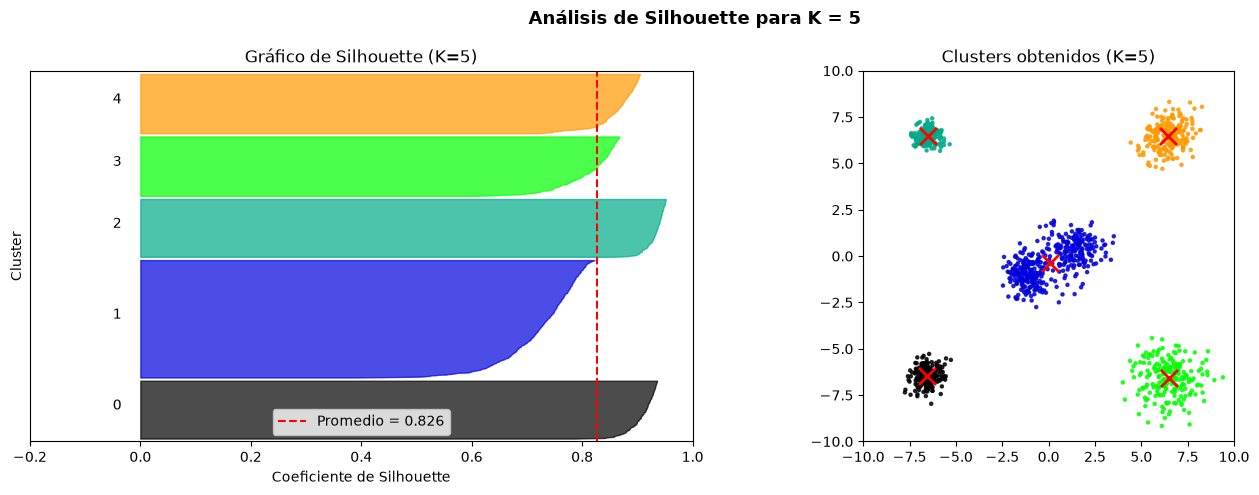

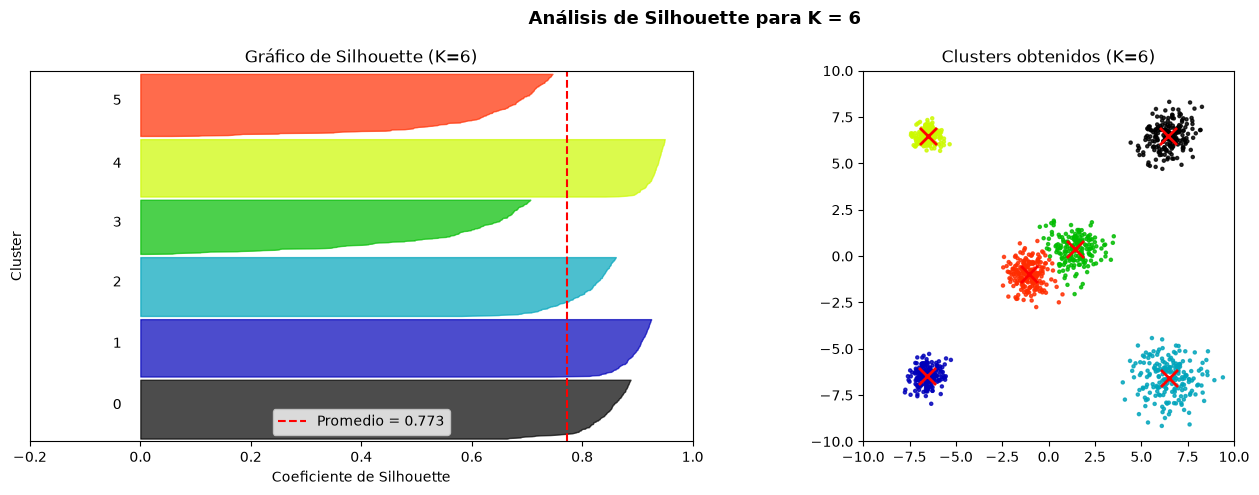

In [9]:
k_candidatos = sorted(set([k_silhouette, n_clusters_true]))  # comparamos el mejor K y el K real (6)

for n_clusters in k_candidatos:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.set_xlim([-0.2, 1])
    ax1.set_ylim([0, len(X_clean) + (n_clusters + 1) * 10])

    clusterer = models[n_clusters]
    cluster_labels = clusterer.labels_
    silhouette_avg = silhouette_score(X_clean, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_clean, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_vals = sample_silhouette_values[cluster_labels == i]
        ith_vals.sort()
        size_i = ith_vals.shape[0]
        y_upper = y_lower + size_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Gráfico de Silhouette (K={n_clusters})")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Promedio = {silhouette_avg:.3f}")
    ax1.legend()
    ax1.set_yticks([])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_clean[:, 0], X_clean[:, 1], marker=".", s=20, c=colors, alpha=0.8)
    centers_k = clusterer.cluster_centers_
    ax2.scatter(centers_k[:, 0], centers_k[:, 1], marker="x", c="red", s=150, linewidths=2)
    ax2.set_xlim(-10, 10); ax2.set_ylim(-10, 10); ax2.set_aspect("equal")
    ax2.set_title(f"Clusters obtenidos (K={n_clusters})")

    plt.suptitle(f"Análisis de Silhouette para K = {n_clusters}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 7. Método basado en ground truth

Como en este caso sí conocemos las etiquetas reales (nosotros generamos los datos), podemos comparar directamente contra ellas con ARI y NMI. También mapeamos cada cluster a la clase real más frecuente dentro de él para sacar accuracy y matriz de confusión. En un problema real normalmente no tendríamos estas etiquetas, así que este método se usa más que todo para validar el algoritmo.


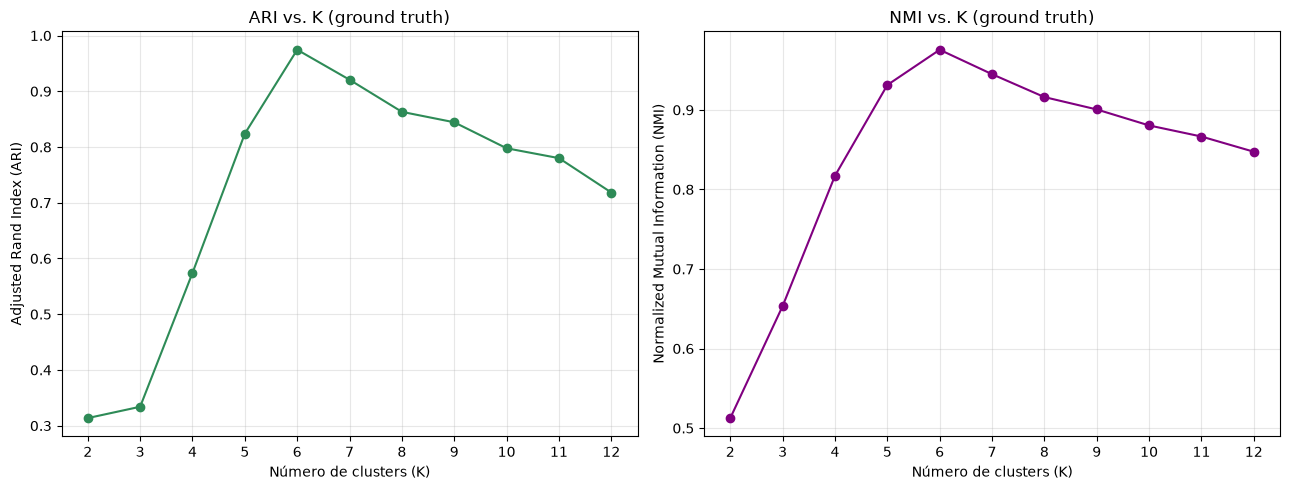

K óptimo según ARI: 6 (ARI = 0.9746)
K óptimo según NMI: 6 (NMI = 0.9756)
Número real de clusters generados: 6


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), ari_scores, marker="o", color="seagreen")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Adjusted Rand Index (ARI)")
axes[0].set_title("ARI vs. K (ground truth)")
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), nmi_scores, marker="o", color="purple")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Normalized Mutual Information (NMI)")
axes[1].set_title("NMI vs. K (ground truth)")
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

k_ari = list(k_range)[int(np.argmax(ari_scores))]
k_nmi = list(k_range)[int(np.argmax(nmi_scores))]
print(f"K óptimo según ARI: {k_ari} (ARI = {max(ari_scores):.4f})")
print(f"K óptimo según NMI: {k_nmi} (NMI = {max(nmi_scores):.4f})")
print(f"Número real de clusters generados: {n_clusters_true}")


Accuracy (K=6, tras mapear clusters a clases reales): 0.9890

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       197
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       195
           3       1.00      1.00      1.00       200
           4       0.94      0.99      0.97       199
           5       0.99      0.94      0.97       195

    accuracy                           0.99      1186
   macro avg       0.99      0.99      0.99      1186
weighted avg       0.99      0.99      0.99      1186



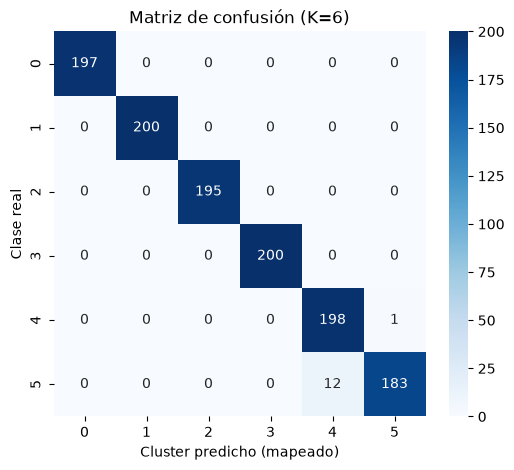

In [11]:
def map_clusters_to_labels(y_true_, y_pred_):
    """Asigna a cada cluster predicho la etiqueta real más frecuente dentro de él."""
    new_labels = np.zeros_like(y_pred_)
    y_true_np = np.array(y_true_)
    for cluster in np.unique(y_pred_):
        mask = y_pred_ == cluster
        new_labels[mask] = mode(y_true_np[mask], keepdims=False)[0]
    return new_labels

# Evaluamos con K = número real de clusters (6)
labels_pred_final = models[n_clusters_true].labels_[mask_known_cluster]
labels_mapped = map_clusters_to_labels(y_true_clean, labels_pred_final)

print(f"Accuracy (K={n_clusters_true}, tras mapear clusters a clases reales):",
      f"{accuracy_score(y_true_clean, labels_mapped):.4f}\n")
print(classification_report(y_true_clean, labels_mapped))

cm_matrix = confusion_matrix(y_true_clean, labels_mapped)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Cluster predicho (mapeado)")
plt.ylabel("Clase real")
plt.title(f"Matriz de confusión (K={n_clusters_true})")
plt.show()


## 8. Comparación de resultados

Juntamos todo en una tabla para ver el K que sugiere cada método.


In [12]:
resumen = pd.DataFrame({
    "K": list(k_range),
    "Inercia": inertias,
    "Silhouette": silhouette_avgs,
    "ARI": ari_scores,
    "NMI": nmi_scores,
})

print("K óptimo por método:")
print(f"  - Codo (Elbow, heurística):  K = {k_codo}")
print(f"  - Silhouette:                K = {k_silhouette}")
print(f"  - Ground truth (ARI):        K = {k_ari}")
print(f"  - Ground truth (NMI):        K = {k_nmi}")
print(f"  - Número real de clusters:   K = {n_clusters_true}")

resumen.style.highlight_max(subset=["Silhouette", "ARI", "NMI"], color="lightgreen") \
              .highlight_min(subset=["Inercia"], color="lightyellow")


K óptimo por método:
  - Codo (Elbow, heurística):  K = 5
  - Silhouette:                K = 5
  - Ground truth (ARI):        K = 6
  - Ground truth (NMI):        K = 6
  - Número real de clusters:   K = 6


,K,Inercia,Silhouette,ARI,NMI
0,2,42257.411751,0.378835,0.313655,0.512632
1,3,26398.517871,0.545875,0.333989,0.653463
2,4,12629.830708,0.682496,0.574157,0.817278
3,5,1891.908374,0.826411,0.823996,0.931332
4,6,1080.174768,0.773065,0.974556,0.975623
5,7,952.874932,0.690713,0.920731,0.944904
6,8,870.267280,0.606790,0.863140,0.916121
7,9,786.183154,0.613645,0.844395,0.900578
8,10,711.198342,0.562421,0.797772,0.880477
9,11,661.832783,0.560741,0.780065,0.866531


Como esperábamos, ARI y NMI sí pegan con K=6, porque tienen las etiquetas reales. El codo y Silhouette dan K=5, seguramente porque terminan fusionando los clusters 4 y 5 al estar solapados. Tiene sentido: sin ground truth, esos dos métodos no tienen forma de saber que en realidad son dos grupos distintos.

## 9. Modelo final

Corremos K-Means con K=6 (el valor real) sobre los datos limpios y graficamos el resultado.


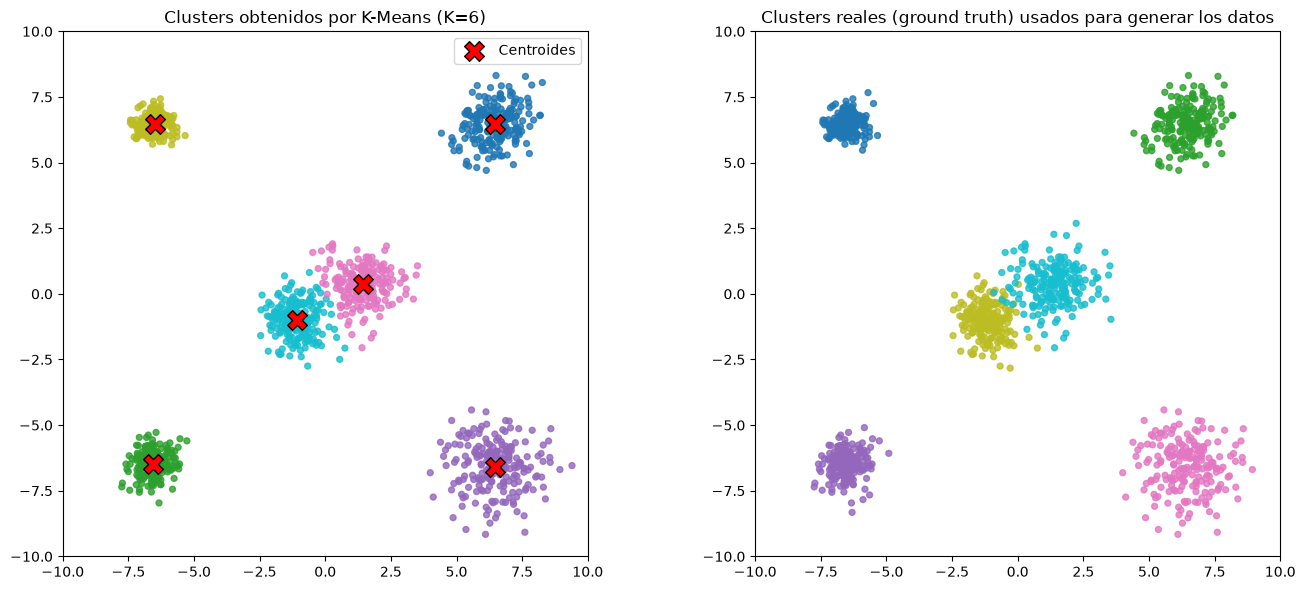

Centroides finales:
[[ 6.46021837  6.47613163]
 [-6.5459754  -6.46958353]
 [ 6.47574063 -6.58374142]
 [ 1.43849316  0.36756488]
 [-6.50320183  6.48231987]
 [-1.07708329 -0.99147529]]


In [13]:
K_final = n_clusters_true
kmeans_final = models[K_final]
labels_final = kmeans_final.labels_
centroids_final = kmeans_final.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_clean[:, 0], X_clean[:, 1], c=labels_final, cmap="tab10", s=18, alpha=0.8)
axes[0].scatter(centroids_final[:, 0], centroids_final[:, 1], c="red", marker="X", s=200,
                edgecolors="black", linewidths=1, label="Centroides")
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10); axes[0].set_aspect("equal")
axes[0].set_title(f"Clusters obtenidos por K-Means (K={K_final})")
axes[0].legend()

axes[1].scatter(X_clusters[:, 0], X_clusters[:, 1], c=y_true, cmap="tab10", s=18, alpha=0.8)
axes[1].set_xlim(-10, 10); axes[1].set_ylim(-10, 10); axes[1].set_aspect("equal")
axes[1].set_title("Clusters reales (ground truth) usados para generar los datos")

plt.tight_layout()
plt.show()

print("Centroides finales:")
print(centroids_final)


## Conclusiones

Los tres métodos no siempre coinciden, y eso es justo lo interesante del ejercicio: el codo y Silhouette (no supervisados) subestimaron K por el solapamiento entre dos clusters, mientras que el método con ground truth sí identificó los 6 grupos reales. En la práctica casi nunca vamos a tener etiquetas reales, así que hay que tener presente esta limitación al elegir K solo con codo/Silhouette.
